Nama: Dimas Satria Prayoga

# Import Library

In [3]:
# Core Deep Learning & Computer Vision
import tensorflow as tf
import keras
import cv2 # OpenCV for image processing and computer vision tasks
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetV2B0, ResNet152, VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image
# Comments:
# - TensorFlow/Keras: Frameworks for building and training deep learning models.
# - EfficientNet/ResNet/VGG: Pre-trained architectures for transfer learning.
# - OpenCV (cv2): Used for advanced image manipulation and loading.

# Data Manipulation & Analysis
import pandas as pd
import numpy as np
# Comments:
# - Pandas: Essential for handling datasets and CSV files.
# - NumPy: Provides support for large, multi-dimensional arrays and matrices.

# Visualization & Plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Comments:
# - Matplotlib: The standard library for creating static, animated, and interactive visualizations.
# - Seaborn: Built on top of matplotlib; great for heatmaps and statistical charts.

# Machine Learning Utilities & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Comments:
# - Scikit-learn (sklearn): Used for data splitting and comprehensive model evaluation metrics.
# - itertools: Useful for iterating through colors/labels when plotting ROC curves.

# System, Files, & Environment
import kagglehub
import os
import shutil
from google.colab import files
from google.colab import drive # Import drive module

# Comments:
# - kagglehub: Helper to download datasets directly from Kaggle.
# - os/shutil: Standard Python tools for file management (creating folders, moving files).
# - google.colab: Specific tools for uploading/downloading files in Colab environment.

# Miscellaneous Utilities
import warnings
import time
import random

# Comments:
# - warnings: Used to ignore or filter out annoying non-critical alerts.
# - time: To track training duration or execution speed.
# - random: Essential for setting seeds to ensure experiment reproducibility.

drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


# Dataset Downloaded from Kaggle

In [4]:
# Determine the path for parent directory and each type of case
parent_dir = "/content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image"
lung_opacity_path = "/content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/lung_opacity"
normal_path = "/content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/normal"
viral_pneumonia_path = "/content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/viral_pneumonia"

# Print path to verify
print(f"Parent Directory Path: {parent_dir}")
print(f"Lung Opacity Path: {lung_opacity_path}")
print(f"Normal Path: {normal_path}")
print(f"Viral Pneumonia Path: {viral_pneumonia_path}")

Parent Directory Path: /content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image
Lung Opacity Path: /content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/lung_opacity
Normal Path: /content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/normal
Viral Pneumonia Path: /content/drive/MyDrive/Datasets_machine_learning/lung_x_ray_image/viral_pneumonia


# Exploratory Data Analysis (EDA)

In [5]:
# Counting the number of files in each folder
num_lung_opacity = len(os.listdir(lung_opacity_path))
num_normal = len(os.listdir(normal_path))
num_viral_pneumonia = len(os.listdir(viral_pneumonia_path))

# Print path to verify
print("Number of Lung Opacity Case Data :", num_lung_opacity)
print("Number of Normal Case Data :", num_normal)
print("Number of Viral Pneumonia Data :", num_viral_pneumonia)

# Calculating the overall total
total_data = num_lung_opacity + num_normal + num_viral_pneumonia
print("Total Seluruh Data :", total_data)

Number of Lung Opacity Case Data : 1125
Number of Normal Case Data : 1250
Number of Viral Pneumonia Data : 1100
Total Seluruh Data : 3475


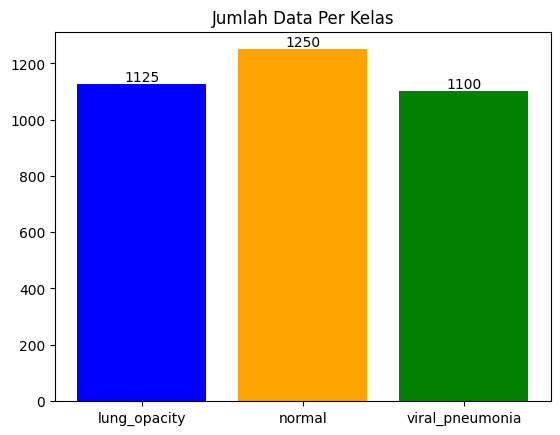

In [6]:
# Data Folders
data_folders = {
  "lung_opacity": num_lung_opacity,
  "normal": num_normal,
  "viral_pneumonia": num_viral_pneumonia,
}

# Count the number of files and at the same time get the category names
labels = list(data_folders.keys())
counts = list(data_folders.values())

# show the graph
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Add numbers above each bar for clarity
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

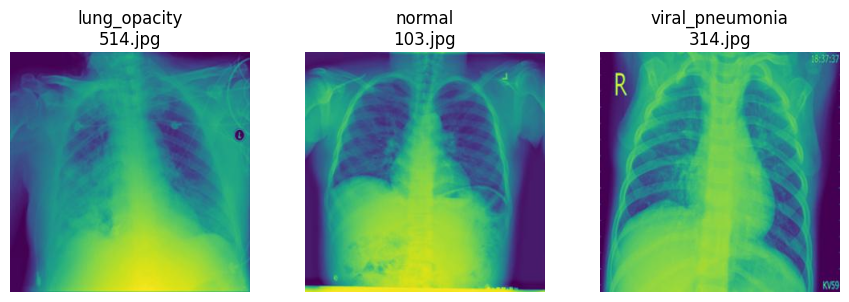

In [7]:
# List of paths and labels according to the variables in your notebook
class_paths = {
  "lung_opacity": lung_opacity_path,
  "normal": normal_path,
  "viral_pneumonia": viral_pneumonia_path
}

# Preparing the plot
plt.figure(figsize=(9, 3))

for i, (label, path) in enumerate(class_paths.items()):
  # Taking a list of files and selecting the first file
  img_name = os.listdir(path)[0]
  img_path = os.path.join(path, img_name)

  # Reading images using OpenCV
  img = cv2.imread(img_path)
  # Conversion from BGR to RGB (Because OpenCV reads in BGR format)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # Display image
  plt.subplot(1, 3, i + 1)
  plt.imshow(img)
  plt.title(f"{label}\n{img_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation

Found 2433 images belonging to 3 classes.
Found 1042 images belonging to 3 classes.
Batch Size: 32



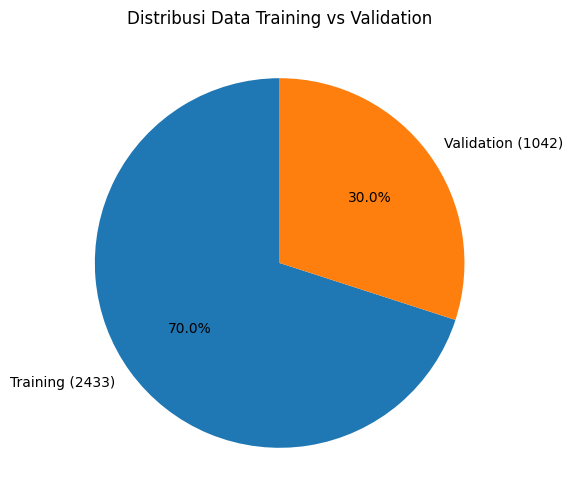

In [8]:
# Converting all images to 224x224 pixels
IMG_HEIGHT = 224
IMG_WIDTH = 224

# The model learns from 32 images per training step
BATCH_SIZE = 32 # Hyperparameter (BATCH_SIZE = 16, 32, 64)

# 1. Train Generator (70%)
# Create a generator object to process training data.
train_datagen = ImageDataGenerator(
  # Adjusting image pixel values according to the standards required by the EfficientNetV2 model.
  preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
  # Rotate the image randomly up to a maximum of 30 degrees.
  rotation_range = 30,
  # Randomly zoom in or out of the image by 30%.
  zoom_range = 0.30,
  # Shift the image horizontally by 30% of the total width.
  width_shift_range = 0.30,
  # Shift the image vertically by 30% of the total height.
  height_shift_range = 0.30,
  # Apply an angular distortion effect (like tilted) of 30%.
  shear_range = 0.30,
  # Flipping the image horizontally (like a mirror).
  horizontal_flip = True,
  # Flip the image vertically
  vertical_flip = True,
  # Adjust the brightness level
  brightness_range=[0.5, 2],
  # The area is filled with the nearest pixel color.
  fill_mode = "nearest",
  validation_split = 0.3
)

# 2. Validation Generator (30%)
# Validation data is not given augmentation
validation_datagen = ImageDataGenerator(
  preprocessing_function=tf.keras.applications.efficientnet_v2.preprocess_input,
  validation_split = 0.3
)

# Pull images from a folder to be used during the training process.
train_generator = train_datagen.flow_from_directory(
  parent_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'categorical',
  subset = 'training',
  seed = 42
)

# Pull images from a folder to be used during the validation process.
validation_generator = validation_datagen.flow_from_directory(
  parent_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'categorical',
  subset = 'validation',
  seed = 42
)

# Preparing data for visualization
print("Batch Size:", BATCH_SIZE)
counts = [train_generator.samples, validation_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})']
print("")

# Creating a Pie Chart (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

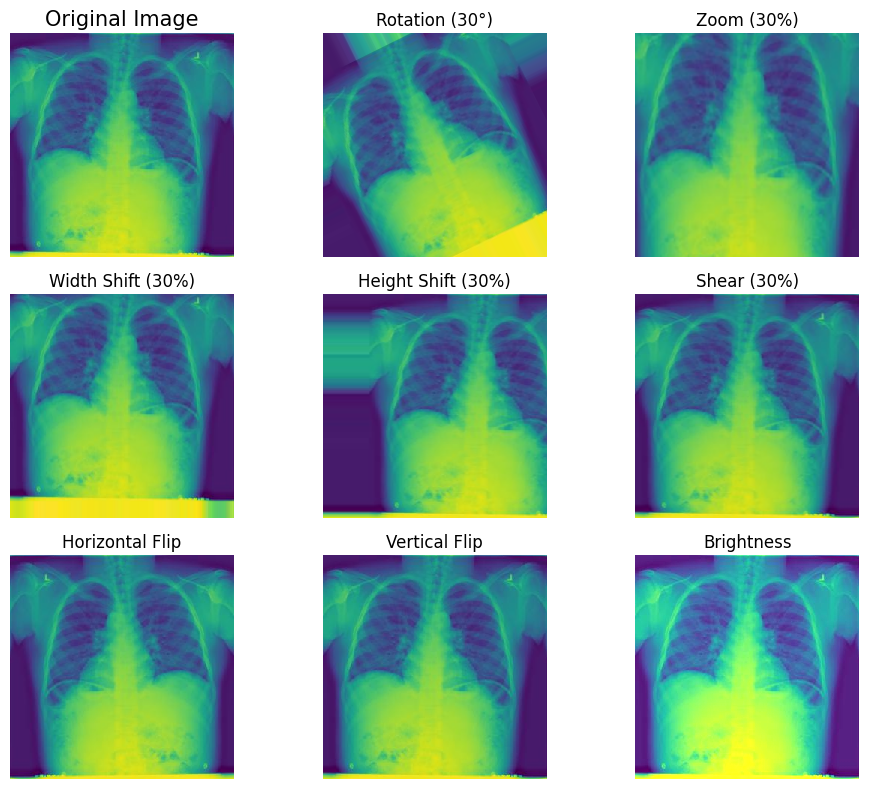

In [9]:
# Data Augmentation Visualization
# Select one example image from the dataset folder
sample_img_path = os.path.join(normal_path, os.listdir(normal_path)[0])
img = load_img(sample_img_path, target_size = (IMG_HEIGHT, IMG_WIDTH))

# Convert the image into an array and add a batch dimension
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # To Become (1, 224, 224, 3)

# List of parameters to be visualized
augmentations = {
  "Rotation (30°)": ImageDataGenerator(rotation_range=30, fill_mode='nearest'),
  "Zoom (30%)": ImageDataGenerator(zoom_range=0.30, fill_mode='nearest'),
  "Width Shift (30%)": ImageDataGenerator(width_shift_range=0.30, fill_mode='nearest'),
  "Height Shift (30%)": ImageDataGenerator(height_shift_range=0.30, fill_mode='nearest'),
  "Shear (30%)": ImageDataGenerator(shear_range=0.30, fill_mode='nearest'),
  "Horizontal Flip": ImageDataGenerator(horizontal_flip=True, fill_mode='nearest'),
  "Vertical Flip": ImageDataGenerator(vertical_flip=True, fill_mode='nearest'),
  "Brightness": ImageDataGenerator(brightness_range=[0.5, 2], fill_mode='nearest')
}

# Prepare the plot
plt.figure(figsize=(10, 8)) # Adjusted figure size for more augmentations

# Show the original image in the first position
plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title("Original Image", fontsize=15)
plt.axis('off')

# Show the results of each augmentation
for i, (name, gen) in enumerate(augmentations.items(), 2):
  # Take one batch of transformation results
  for batch in gen.flow(x, batch_size=1):
    plt.subplot(3, 3, i) # Adjusted subplot layout
    plt.imshow(batch[0].astype('uint8'))
    plt.title(name)
    plt.axis('off')
    break

plt.tight_layout()
plt.show()

In [10]:
# Get all file paths and labels from parent_dir
filenames = []
labels = []

# Reading the category (Class) folder
for category in os.listdir(parent_dir):
  # Creating a complete folder address
  category_path = os.path.join(parent_dir, category)
  # Make sure it is a folder
  if os.path.isdir(category_path):
    # Register every image file
    for file in os.listdir(category_path):
      filenames.append(os.path.join(category_path, file))
      labels.append(category)

# Creating a table (DataFrame)
df = pd.DataFrame({'filename': filenames, 'label': labels})

# Division: 70% Train, 30% Remaining (for Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
# Division of the Remaining (30%) into two: 15% Val and 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training Images: {len(train_df)} Images")
print(f"Validation Images: {len(val_df)} Images")
print(f"Testing Images: {len(test_df)} Images")

Training Images: 2432 Images
Validation Images: 521 Images
Testing Images: 522 Images


# Split Data

Found 2432 validated image filenames belonging to 3 classes.
Found 521 validated image filenames belonging to 3 classes.
Found 522 validated image filenames belonging to 3 classes.



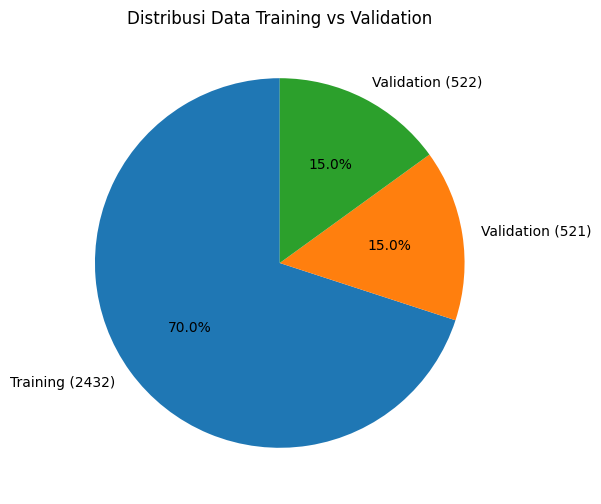

In [11]:
# Use the augmentation parameters that you have defined in train_datagen earlier

# 1. Train Generator (70%)
# This line creates a data generator from the train_datagen object
train_generator = train_datagen.flow_from_dataframe(
  dataframe=train_df, # The dataframe train_df is used as the data source
  x_col='filename', # Column in the dataframe that contains the name or location of the image file
  y_col='label', # Column containing the class label of each image.
  target_size=(IMG_WIDTH, IMG_HEIGHT), # The image size that will be used by the model.
  batch_size=BATCH_SIZE, # Determining batch size
  class_mode='categorical', # Determining the type of classification
  shuffle=True, # Improving the model's generalization ability
  seed=42 # Consistent every time the experiment is conducted
)

# 2. Validation Generator (15%)
validation_generator = validation_datagen.flow_from_dataframe(
  dataframe=val_df, # The dataframe val_df is used as the data source
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=BATCH_SIZE,
  class_mode='categorical',
  shuffle=True,
  seed=42
)

# 3. Test Generator (15%) - Use validation_datagen because it only needs rescale
test_generator = validation_datagen.flow_from_dataframe(
  dataframe=test_df, # The dataframe test_df is used as the data source
  x_col='filename',
  y_col='label',
  target_size=(IMG_WIDTH, IMG_HEIGHT),
  batch_size=1, # (best practice)
  class_mode='categorical',
  shuffle=False, # So that the sequence of prediction results can be easily checked later
  seed=42
)

# 1. Get the number of data from the generator
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Validation ({counts[2]})']
print("")

# 2. Circle plot diagram (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

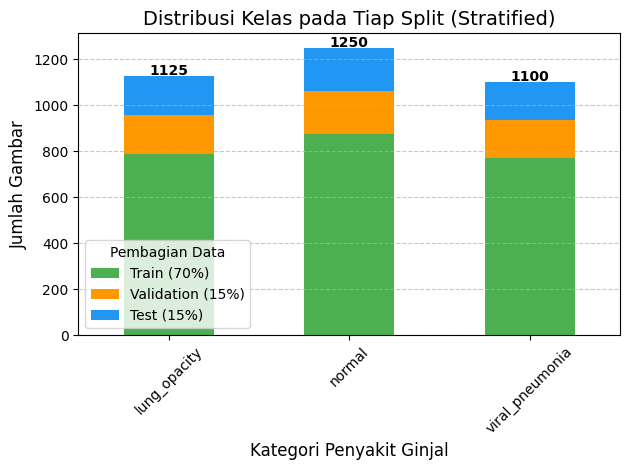

In [12]:
# Count the number of data per class in each split
train_counts = train_df['label'].value_counts().sort_index()
val_counts = val_df['label'].value_counts().sort_index()
test_counts = test_df['label'].value_counts().sort_index()

# Prepare Data for Plotting
categories = train_counts.index
df_plot = pd.DataFrame({ # Corrected 'Dataframe' to 'DataFrame'
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Creating a Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Distribusi Kelas pada Tiap Split (Stratified)", fontsize=14)
plt.xlabel("Kategori Penyakit Ginjal", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.legend(title="Pembagian Data")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add number labels above each bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# Calculating the total of all data after being divided into three parts
df_plot['Total'] = df_plot['Train (70%)'] + df_plot['Validation (15%)'] + df_plot['Test (15%)']
print(df_plot)

                 Train (70%)  Validation (15%)  Test (15%)  Total
label                                                            
lung_opacity             787               169         169   1125
normal                   875               187         188   1250
viral_pneumonia          770               165         165   1100


# Model Building 1 (EfficientNetV2B0)

In [14]:
# 1. Define the Model Builder Function
def build_EfficientNetV2B0_model():
  # Loading the Base Model (EfficientNetV2B0)
  base_model = EfficientNetV2B0(
    # Replacing with a new layer that specifically predicts 3 lung conditions.
    include_top = False,
    # Using weights (intelligence) that have already been learned from (1.2 million images)
    weights = 'imagenet',
    input_tensor = None,
    # Determining the input image size (224x224 pixels with 3 color channels (RGB).
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    pooling = None,
    classifier_activation = "softmax",
    name = "efficientnetv2-b0"
  )

  # Locking the original knowledge of the base_model so that it does not get damaged when training new layers.
  base_model.trainable = False

  # Constructing a Sequential Architecture
  model = models.Sequential([
    # Model ini sudah dilatih menggunakan jutaan gambar umum (ImageNet)
    base_model,
    # Mengurangi dimensi data secara drastis untuk mencegah overfitting
    layers.GlobalAveragePooling2D(),
    # Mempelajari hubungan logika antara tekstur gambar dengan jenis penyakit
    layers.Dense(256, activation='relu'),
    # Lapisan ini menstabilkan hasil perhitungan dari lapisan sebelumnya
    layers.BatchNormalization(),
    # Teknik pengamanan yang secara acak "mematikan" 30% saraf (neuron)
    layers.Dropout(0.3),
    # Lapisan terakhir yang menentukan hasil akhir diagnosa.
    layers.Dense(3, activation='softmax') # 3 Kelas:
  ])

  return model

# 2. Panggil Fungsi untuk Membuat Model
EfficientNetV2B0_model = build_EfficientNetV2B0_model()

# 3. Tampilkan Ringkasan Arsitektur (Model Summary)
# Ini akan menampilkan jumlah parameter dan urutan layer secara detail
EfficientNetV2B0_model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,249,043 (23.84 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 5,919,824 (22.58 MB)

# Tuning Hyperparameter 1
Epochs = 10 <br>
Learning_rate = 0.001 <br>

In [ ]:
# 1. Mulai Proses Pelatihan
epochs=10
learning_rate=0.001

EfficientNetV2B0_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), #Hyperparameter
  loss='categorical_crossentropy',
  metrics=[
    'accuracy'
  ]
)

history = EfficientNetV2B0_model.fit(
  train_generator,
  epochs=epochs, #Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

# Tuning Hyperparameter 2
epochs = 20 <br>
learning rate = 0.001 <br>

In [ ]:
# Mulai Proses Pelatihan
epochs=20 #Hyperparameter
learning_rate=0.001 #Hyperparameter

EfficientNetV2B0_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), #Hyperparameter
  loss='categorical_crossentropy',
  metrics=[
    'accuracy'
  ]
)

history2 = EfficientNetV2B0_model.fit(
  train_generator,
  epochs=epochs, #Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

# Tuning Hyperparameter 3
Epoch = 20 <br>
Learning_rate = 0.0001 <br>

In [17]:
epochs=20 #Hyperparameter
learning_rate=0.0001 #Hyperparameter

EfficientNetV2B0_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), #Hyperparameter
  loss='categorical_crossentropy',
  metrics=[
    'accuracy'
  ]
)

history3 = EfficientNetV2B0_model.fit(
  train_generator,
  epochs=epochs, #Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8335 - loss: 0.4286 - val_accuracy: 0.8599 - val_loss: 0.3672
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.8405 - loss: 0.4166 - val_accuracy: 0.8599 - val_loss: 0.3445
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8359 - loss: 0.4104 - val_accuracy: 0.8464 - val_loss: 0.3631
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8499 - loss: 0.3786 - val_accuracy: 0.8522 - val_loss: 0.3902
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8651 - loss: 0.3532 - val_accuracy: 0.8637 - val_loss: 0.3431
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8540 - loss: 0.3840 - val_accuracy: 0.8503 - val_loss: 0.3599
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8577 - loss: 0.3485 - val_accuracy: 0.8580 - val_loss: 0.3380
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8544 - loss: 0.3655 - val_accuracy: 0.8637 - v

# Tuning Hyperparameter 4

In [16]:
epochs=20 #Hyperparameter
learning_rate=0.00001 #Hyperparameter

EfficientNetV2B0_model.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), #Hyperparameter
  loss='categorical_crossentropy',
  metrics=[
    'accuracy'
  ]
)

history4 = EfficientNetV2B0_model.fit(
  train_generator,
  epochs=epochs, #Hyperparameter
  validation_data=validation_generator,
  verbose=1
)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 1046s 14s/step - accuracy: 0.7081 - loss: 0.7572 - val_accuracy: 0.7927 - val_loss: 0.6331
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7278 - loss: 0.6815 - val_accuracy: 0.8177 - val_loss: 0.5316
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7381 - loss: 0.6560 - val_accuracy: 0.8177 - val_loss: 0.4698
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.7475 - loss: 0.6330 - val_accuracy: 0.8234 - val_loss: 0.4378
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7512 - loss: 0.6109 - val_accuracy: 0.8215 - val_loss: 0.4266
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7743 - loss: 0.5549 - val_accuracy: 0.8311 - val_loss: 0.4214
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7907 - loss: 0.5346 - val_accuracy: 0.8311 - val_loss: 0.4212
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7858 - loss: 0.5286 - val_accuracy: 0.8369 -

# Visualisasi Training

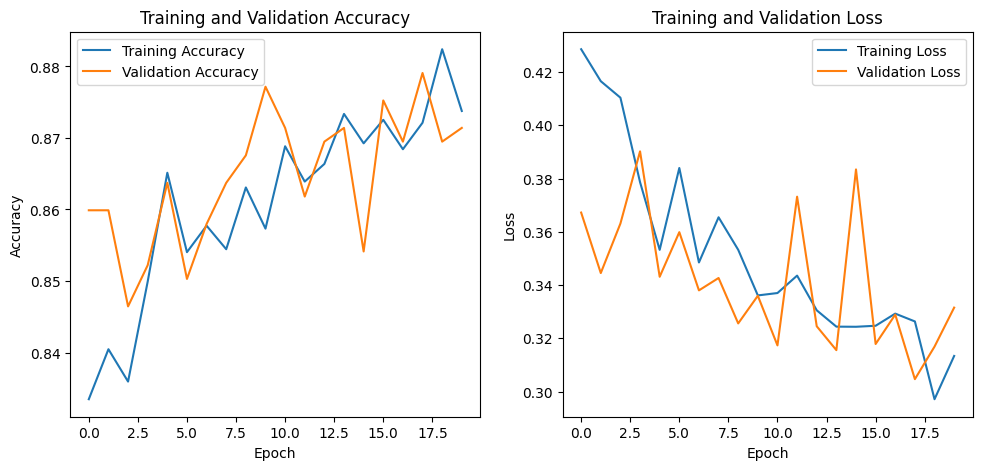

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 3, 2)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Evaluasi Model

In [20]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# Prediksi Model
start_time = time.time()

Y_pred = EfficientNetV2B0_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder

# Hitung Akurasi
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Hyperparameter: ")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

522/522 ━━━━━━━━━━━━━━━━━━━━ 208s 396ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.0001
Epoch: 20
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.8774
Total Waktu Prediksi : 209.84 detik


In [21]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                 precision    recall  f1-score   support

   lung_opacity      0.902     0.817     0.857       169
         normal      0.783     0.920     0.846       188
viral_pneumonia      0.993     0.891     0.939       165

       accuracy                          0.877       522
      macro avg      0.893     0.876     0.881       522
   weighted avg      0.888     0.877     0.879       522




--- Confusion Matrix ---


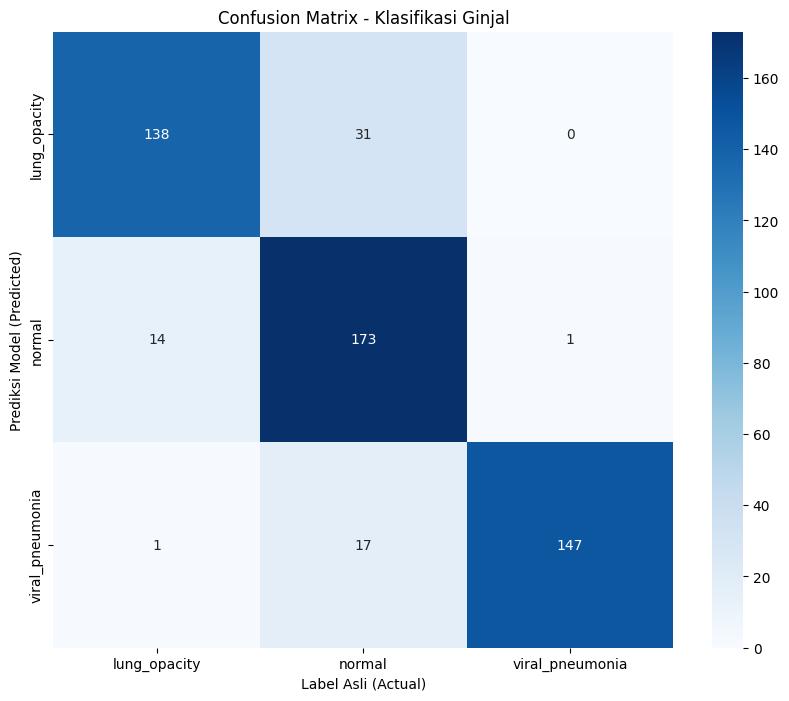

In [22]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

# New Image Prediction

Saving viral_pneumonia.jpeg to viral_pneumonia (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


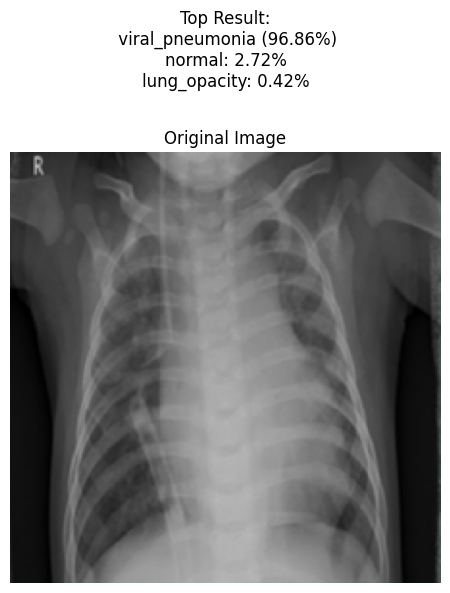

In [27]:
def predict_with_upload(model, class_indices):
  # 1. Trigger fitur upload file
  uploaded = files.upload()

  for file_name in uploaded.keys():
    # 2. Load gambar asli untuk tampilan visual
    img = image.load_img(file_name, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)

    # Tambahkan dimensi batch (1, 224, 224, 3)
    img_ready = np.expand_dims(img_array, axis=0) # Use img_array directly

    # 3. Prediksi
    predictions = model.predict(img_ready)[0]
    class_names = list(class_indices.keys())

    # 4. Mengolah Hasil
    results = []
    for i in range(len(class_names)):
        results.append((class_names[i], predictions[i] * 100))

    # Sort dari persentase tertinggi
    results.sort(key=lambda x: x[1], reverse=True)

    # 5. Visualisasi (Hanya Original Image)
    plt.figure(figsize=(6, 6))

    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Tampilkan Teks Prediksi
    display_text = f"Top Result:\n {results[0][0]} ({results[0][1]:.2f}%)\n"
    for name, prob in results[1:]:
      display_text += f"{name}: {prob:.2f}%\n"

    plt.suptitle(display_text, fontsize=12)
    plt.tight_layout()
    plt.show()

# Cara Menjalankan:
# Contoh Prediksi Class Cyst
predict_with_upload(EfficientNetV2B0_model, train_generator.class_indices)

Saving lung_opacity.jpeg to lung_opacity.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


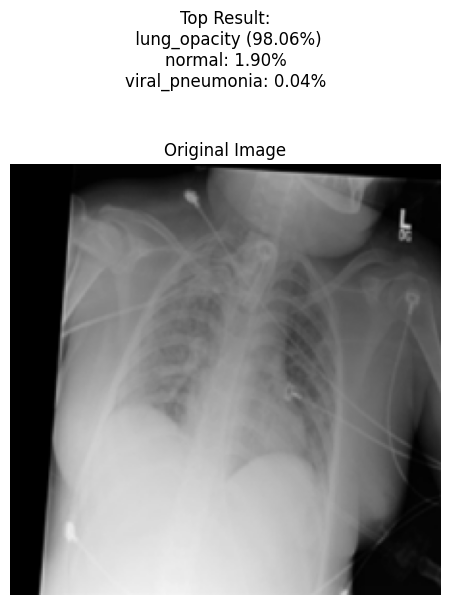

In [26]:
predict_with_upload(EfficientNetV2B0_model, train_generator.class_indices)

Saving normal2.jpeg to normal2.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


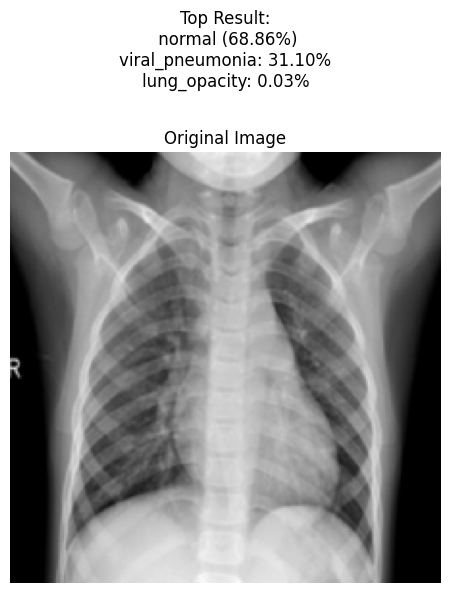

In [30]:
predict_with_upload(EfficientNetV2B0_model, train_generator.class_indices)